<a href="https://colab.research.google.com/github/sipun40/customer_classifcation/blob/main/customer_classifiaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
np.random.seed(42)

In [ ]:
n_customers=500

In [ ]:
ages = np.random.randint(18, 65, n_customers)
gender = np.random. randint(0,2,n_customers)
income = np.random.normal(50, 15, n_customers).round(2)
purchase_amount = np.random.randint(10, 1000, n_customers)


In [ ]:
sudeep_values = ((income<40)&(purchase_amount<100)).astype(int)

In [ ]:
df = pd.DataFrame({
    "age": ages,
    "gender": gender,
    "income": income,
    "purchase_amount": purchase_amount,
    "sudeep":sudeep_values
})

In [ ]:
df.to_csv("customer_data.csv", index=False)

In [ ]:
print(df.head())

   age  gender  income  purchase_amount  sudeep
0   61       1   47.42              614       0
1   49       1   33.38              388       0
2   28       0   46.92               82       0
3   39       1   85.01              932       0
4   39       1   54.38              931       0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              500 non-null    int64  
 1   gender           500 non-null    int64  
 2   income           500 non-null    float64
 3   purchase_amount  500 non-null    int64  
 4   sudeep           500 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 19.7 KB


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
income,0
purchase_amount,0
sudeep,0


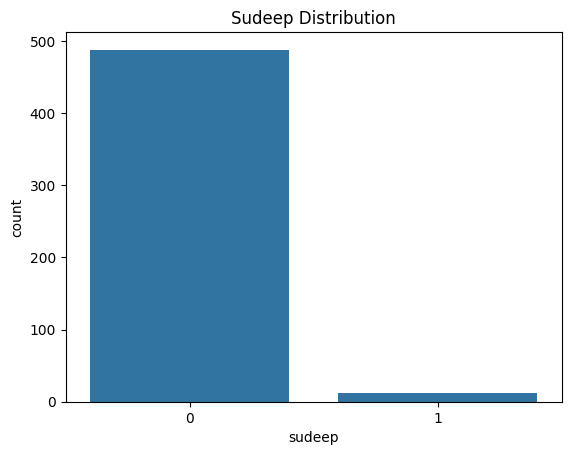

In [ ]:
sns.countplot(x="sudeep",data=df)
plt.title("Sudeep Distribution")
plt.show()

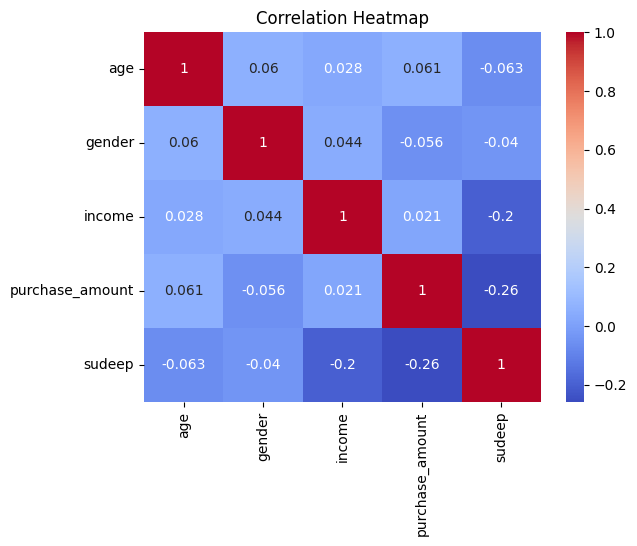

In [ ]:
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
x=df.drop("sudeep",axis=1)
y=df["sudeep"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [ ]:
print(model.score(x_train,y_train))
print(model.score(x_test,y_test))

0.995
1.0


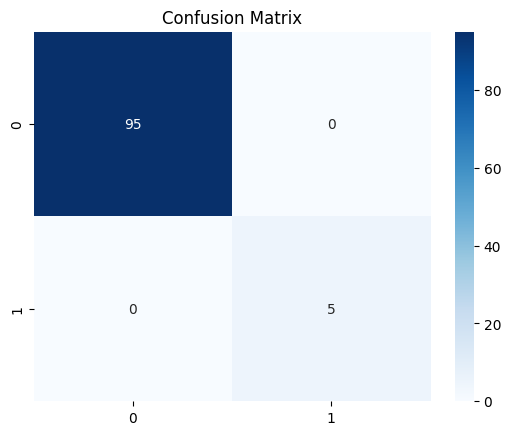

In [ ]:
cm=confusion_matrix(y_test,model.predict(x_test))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
classification_report(y_test,model.predict(x_test))

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        95\n           1       1.00      1.00      1.00         5\n\n    accuracy                           1.00       100\n   macro avg       1.00      1.00      1.00       100\nweighted avg       1.00      1.00      1.00       100\n'

In [ ]:

new_customer = pd.DataFrame({
    "age": [30],
    "gender": [1],
    "income": [60],
    "purchase_amount": [150]
})

In [ ]:
prediction = model.predict(new_customer)[0]
print("prediction",prediction)
if prediction == 1:
    print("The customer is likely to make a purchase.")
else:
    print("The customer is not likely to make a purchase.")

prediction 0
The customer is not likely to make a purchase.
